# ColorMNIST Data

This notebook demonstrates how to load and analyze the generated ColorMNIST data.


In [2]:
# --- Imports
import os, math, json, itertools, numpy as np, torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm

from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoLarsIC
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import joblib

# --- Paths
DATA_DIR = 'data/cmnist'  # adjust if needed
LL_FILE = os.path.join(DATA_DIR, 'dll_samples.pkl')
HL_FILE = os.path.join(DATA_DIR, 'dhl_samples.pkl')
OMEGA_FILE = os.path.join(DATA_DIR, 'intervention_mapping.pkl')

# --- Determinism
def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# --- Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE


device(type='cpu')

In [3]:
# Load ColorMNIST tuples
Dll_samples = torch.load(LL_FILE)     # dict-like with keys per intervention; using observational via [None] later if present in your pipeline
Dhl_samples = torch.load(HL_FILE)
omega = torch.load(OMEGA_FILE)

# In your generation, observational is usually at key None
ll_obs = Dll_samples[None]            # (final_images, gray_images, digits, colors)
hl_obs = Dhl_samples[None]            # shape (N, 21) = [10 one-hot digit | 10 one-hot color | target feature]

def ensure_tanh_scaled(images: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        imin = images.min().item()
        imax = images.max().item()
    if imin >= -1.05 and imax <= 1.05:
        if imin >= -0.01 and imax <= 1.01:
            return images * 2.0 - 1.0
        return images
    eps = 1e-8
    images = (images - images.min()) / (images.max() - images.min() + eps)
    return images * 2.0 - 1.0

def r2_imagewise(final_images: torch.Tensor, predictions: torch.Tensor):
    N = final_images.size(0)
    y = final_images.view(N, -1)
    yhat = predictions.view(N, -1)
    ss_res = torch.sum((y - yhat) ** 2)
    ss_tot = torch.sum((y - y.mean()) ** 2)
    r2_global = 1 - (ss_res / (ss_tot + 1e-12))
    y_mean = y.mean(dim=1, keepdim=True)
    ss_res_i = torch.sum((y - yhat) ** 2, dim=1)
    ss_tot_i = torch.sum((y - y_mean) ** 2, dim=1) + 1e-12
    return r2_global.item(), (1 - ss_res_i / ss_tot_i)


In [4]:
# Build HL X, y from one-hot (digits 0:10, colors 10:20), target = last col
X_digits = hl_obs[:, :10].detach().cpu().numpy()
X_colors = hl_obs[:, 10:20].detach().cpu().numpy()
y = hl_obs[:, -1].detach().cpu().numpy()
X = np.concatenate([X_digits, X_colors], axis=1)

# Baseline RidgeCV
ridge = RidgeCV(alphas=np.logspace(-4, 4, 25))
ridge.fit(X, y)
y_hat = ridge.predict(X)
r2_hl_train = r2_score(y, y_hat)

print(f"HL Ridge (one-hot) — train R^2: {r2_hl_train:.4f}")
best_alpha = ridge.alpha_
best_alpha


HL Ridge (one-hot) — train R^2: 0.6568


1.0

In [5]:
def add_digit_color_interactions(Xd, Xc):
    # (N,10)x(N,10) -> (N,100) via outer-products of one-hot
    return (Xd[:, :, None] * Xc[:, None, :]).reshape(Xd.shape[0], -1)

Xd, Xc = X_digits, X_colors
X_inter = add_digit_color_interactions(Xd, Xc)
X_full = np.concatenate([Xd, Xc, X_inter], axis=1)

# 1) RidgeCV on X_full
ridge_full = RidgeCV(alphas=np.logspace(-5, 3, 25))
ridge_full.fit(X_full, y)
r2_ridge_full = r2_score(y, ridge_full.predict(X_full))

# 2) ElasticNetCV (can encourage sparsity; try mild l1_ratio)
enet = ElasticNetCV(l1_ratio=[0.05, 0.1, 0.2, 0.5], alphas=None, cv=5, max_iter=5000)
enet.fit(X_full, y)
r2_enet = r2_score(y, enet.predict(X_full))

# 3) LassoLarsIC (AIC/BIC model selection)
lasso_ic = LassoLarsIC(criterion='aic')
lasso_ic.fit(X_full, y)
r2_lasso_ic = r2_score(y, lasso_ic.predict(X_full))

print(f"HL Ridge (one-hot only)   : {r2_hl_train:.4f}")
print(f"HL Ridge (+ interactions) : {r2_ridge_full:.4f} (alpha={ridge_full.alpha_:.2e})")
print(f"HL ElasticNet (+ inter.)  : {r2_enet:.4f} (l1_ratio={enet.l1_ratio_}, alpha={enet.alpha_:.2e})")
print(f"HL LassoLarsIC (+ inter.) : {r2_lasso_ic:.4f}")
best_hl = max(
    ('ridge_onehot', r2_hl_train, ridge),
    ('ridge_full', r2_ridge_full, ridge_full),
    ('enet_full', r2_enet, enet),
    ('lasso_ic_full', r2_lasso_ic, lasso_ic),
    key=lambda t: t[1]
)
print("Best HL model:", best_hl[0], "R^2:", f"{best_hl[1]:.4f}")
HL_BEST = {'name': best_hl[0], 'model': best_hl[2], 'R2_train': best_hl[1]}


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1641: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


HL Ridge (one-hot only)   : 0.6568
HL Ridge (+ interactions) : 0.6966 (alpha=4.64e+00)
HL ElasticNet (+ inter.)  : 0.6935 (l1_ratio=0.05, alpha=3.76e-04)
HL LassoLarsIC (+ inter.) : 0.6949
Best HL model: ridge_full R^2: 0.6966


In [6]:
def kfold_r2(model_ctor, X, y, k=5, random_state=42, shuffle=True):
    kf = KFold(n_splits=k, shuffle=shuffle, random_state=random_state)
    scores = []
    for tr, te in kf.split(X):
        m = model_ctor()
        m.fit(X[tr], y[tr])
        preds = m.predict(X[te])
        scores.append(r2_score(y[te], preds))
    return np.mean(scores), np.std(scores)

# Choose feature set based on HL_BEST
if 'full' in HL_BEST['name']:
    X_used = X_full
    def ridge_ctor(): return RidgeCV(alphas=np.logspace(-5, 3, 25))
    def enet_ctor():  return ElasticNetCV(l1_ratio=[0.05,0.1,0.2,0.5], cv=5, max_iter=5000)
else:
    X_used = X
    def ridge_ctor(): return RidgeCV(alphas=np.logspace(-4, 4, 25))
    def enet_ctor():  return ElasticNetCV(l1_ratio=[0.05,0.1,0.2,0.5], cv=5, max_iter=5000)

mean_r2_ridge, std_r2_ridge = kfold_r2(ridge_ctor, X_used, y, k=5)
mean_r2_enet, std_r2_enet = kfold_r2(enet_ctor, X_used, y, k=5)

print(f"KFold(5) HL Ridge mean±std R^2: {mean_r2_ridge:.4f} ± {std_r2_ridge:.4f}")
print(f"KFold(5) HL Enet  mean±std R^2: {mean_r2_enet:.4f} ± {std_r2_enet:.4f}")


KFold(5) HL Ridge mean±std R^2: 0.6355 ± 0.0386
KFold(5) HL Enet  mean±std R^2: 0.6345 ± 0.0351


In [13]:
import matplotlib.pyplot as plt
residuals = y - best_hl['model'].predict(X_full)
plt.hist(residuals, bins=30, alpha=0.6)
plt.title("Residual distribution")
plt.show()

# Mean residual per digit/color (should be ~0 if well fit)
digit_means = [residuals[X_digits[:,i]==1].mean() for i in range(10)]
color_means = [residuals[X_colors[:,i]==1].mean() for i in range(10)]
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.bar(range(10), digit_means); plt.title("Mean residual per digit")
plt.subplot(1,2,2); plt.bar(range(10), color_means); plt.title("Mean residual per color")
plt.show()

TypeError: tuple indices must be integers or slices, not str

In [10]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Kernel Ridge with polynomial kernel
kr_poly = KernelRidge(kernel='poly', degree=2, alpha=1.0)
r2_poly = cross_val_score(kr_poly, X_full, y, cv=5, scoring='r2').mean()

# Kernel Ridge with RBF kernel
kr_rbf = KernelRidge(kernel='rbf', gamma=0.5, alpha=1.0)
r2_rbf = cross_val_score(kr_rbf, X_full, y, cv=5, scoring='r2').mean()

# Random Forest (nonlinear baseline)
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
r2_rf = cross_val_score(rf, X_full, y, cv=5, scoring='r2').mean()

print(f"KernelRidge (poly deg=2): {r2_poly:.4f}")
print(f"KernelRidge (RBF γ=0.5):  {r2_rbf:.4f}")
print(f"RandomForest depth=6:    {r2_rf:.4f}")


KernelRidge (poly deg=2): 0.5431
KernelRidge (RBF γ=0.5):  0.6325
RandomForest depth=6:    0.6358


In [14]:
# Decide which "best" holder you have
try:
    BEST_MODEL = HL_BEST['model']
    BEST_NAME = HL_BEST['name']
except:
    # fallback to tuple-based best_hl = (name, r2, model)
    BEST_MODEL = best_hl[2]
    BEST_NAME = best_hl[0]

# Make sure X_used matches your best features
# If your best used interactions, we assume X_full exists; else X.
try:
    X_used  # noqa
except NameError:
    # Try to infer
    if 'full' in BEST_NAME:
        X_used = X_full
    else:
        X_used = X

BEST_MODEL, BEST_NAME, X_used.shape


(RidgeCV(alphas=array([1.00000000e-05, 2.15443469e-05, 4.64158883e-05, 1.00000000e-04,
        2.15443469e-04, 4.64158883e-04, 1.00000000e-03, 2.15443469e-03,
        4.64158883e-03, 1.00000000e-02, 2.15443469e-02, 4.64158883e-02,
        1.00000000e-01, 2.15443469e-01, 4.64158883e-01, 1.00000000e+00,
        2.15443469e+00, 4.64158883e+00, 1.00000000e+01, 2.15443469e+01,
        4.64158883e+01, 1.00000000e+02, 2.15443469e+02, 4.64158883e+02,
        1.00000000e+03])),
 'ridge_full',
 (1000, 120))

In [9]:
import numpy as np
import matplotlib.pyplot as plt

residuals = y - BEST_MODEL.predict(X_used)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(residuals, bins=30, alpha=0.7)
ax.set_title("HL residual distribution")
ax.set_xlabel("residual")
ax.set_ylabel("count")
plt.show()

# Per-digit / per-color mean residual (should be ~0 if unbiased)
digit_means = [residuals[X_digits[:, i]==1].mean() for i in range(10)]
color_means = [residuals[X_colors[:, i]==1].mean() for i in range(10)]

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axs[0].bar(range(10), digit_means); axs[0].set_title("Mean residual per digit"); axs[0].set_xlabel("digit")
axs[1].bar(range(10), color_means); axs[1].set_title("Mean residual per color"); axs[1].set_xlabel("color")
for ax in axs: ax.axhline(0, linestyle='--', linewidth=1)
plt.show()


NameError: name 'y' is not defined

In [16]:
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score

# (assumes X_digits, X_colors, X_inter, X_full, y already in memory)

# build (digit,color) pair ids
dig_ids = np.argmax(X_digits, axis=1)
col_ids = np.argmax(X_colors, axis=1)
pairs = dig_ids * 10 + col_ids
vals, counts = np.unique(pairs, return_counts=True)
freq = dict(zip(vals, counts))
w = np.array([1.0 / freq[p] for p in pairs], dtype=float)
w /= w.mean()  # normalize around 1

# weighted Ridge on interactions
ridge_w = RidgeCV(alphas=np.logspace(-5, 3, 25))
ridge_w.fit(X_full, y, sample_weight=w)
r2_train_w = 1.0 - np.average((y - ridge_w.predict(X_full))**2, weights=w) / np.average((y - y.mean())**2, weights=w)

# weighted 5-fold CV (manual loop because cross_val_score doesn't pass weights to fit by default)
def weighted_cv_r2(model, X, y, w, k=5, seed=42):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    scores = []
    for tr, te in kf.split(X):
        m = RidgeCV(alphas=model.alphas)
        m.fit(X[tr], y[tr], sample_weight=w[tr])
        yhat = m.predict(X[te])
        # unweighted test R^2 (report both can be useful)
        ss_res = ((y[te]-yhat)**2).sum()
        ss_tot = ((y[te]-y[te].mean())**2).sum()
        scores.append(1 - ss_res/ss_tot)
    return np.mean(scores), np.std(scores)

cv_mean_w, cv_std_w = weighted_cv_r2(ridge_w, X_full, y, w, k=5)

print(f"HL Ridge (+interactions, weighted) — train R^2≈ {r2_train_w:.4f}")
print(f"KFold(5) weighted Ridge — mean±std R^2: {cv_mean_w:.4f} ± {cv_std_w:.4f}")
print("best alpha (weighted fit):", ridge_w.alpha_)


HL Ridge (+interactions, weighted) — train R^2≈ 0.6822
KFold(5) weighted Ridge — mean±std R^2: 0.6323 ± 0.0324
best alpha (weighted fit): 10.0


In [17]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# prepare integer labels
dig_ids = np.argmax(X_digits, axis=1)
col_ids = np.argmax(X_colors, axis=1)
y_t = torch.tensor(y, dtype=torch.float32)

class EmbMLP(nn.Module):
    def __init__(self, d_emb=4, h=64):
        super().__init__()
        self.ed = nn.Embedding(10, d_emb)
        self.ec = nn.Embedding(10, d_emb)
        self.mlp = nn.Sequential(
            nn.Linear(2*d_emb + 100, h), nn.ReLU(True),
            nn.Linear(h, h), nn.ReLU(True),
            nn.Linear(h, 1),
        )
        # init
        nn.init.normal_(self.ed.weight, std=0.05)
        nn.init.normal_(self.ec.weight, std=0.05)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, d, c, x_inter):  # d,c: (N,) long; x_inter: (N,100) float
        z = torch.cat([self.ed(d), self.ec(c), x_inter], dim=1)
        return self.mlp(z).squeeze(1)

def kfold_emb_mlp(d_ids, c_ids, X_inter_np, y_np, k=5, seed=42, d_emb=4, h=64, lr=1e-3, wd=1e-4, epochs=400, bs=128):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    r2s = []
    X_inter = torch.tensor(X_inter_np, dtype=torch.float32)
    d_all = torch.tensor(d_ids, dtype=torch.long)
    c_all = torch.tensor(c_ids, dtype=torch.long)
    y_all = torch.tensor(y_np, dtype=torch.float32)

    for tr, te in kf.split(X_inter_np):
        model = EmbMLP(d_emb=d_emb, h=h)
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        crit = nn.SmoothL1Loss(beta=0.01)

        # train
        for _ in range(epochs):
            idx = np.random.permutation(tr)
            for i in range(0, len(idx), bs):
                b = idx[i:i+bs]
                yb = y_all[b]
                pred = model(d_all[b], c_all[b], X_inter[b])
                loss = crit(pred, yb)
                opt.zero_grad(); loss.backward(); opt.step()

        # eval
        with torch.no_grad():
            yhat = model(d_all[te], c_all[te], X_inter[te]).numpy()
        r2s.append(r2_score(y_all[te].numpy(), yhat))
    return float(np.mean(r2s)), float(np.std(r2s))

r2_mean_mlp, r2_std_mlp = kfold_emb_mlp(dig_ids, col_ids, X_inter, y, k=5, d_emb=4, h=64, lr=1e-3, wd=1e-4, epochs=400)
print(f"Emb+MLP 5-fold CV R^2: {r2_mean_mlp:.4f} ± {r2_std_mlp:.4f}")


Emb+MLP 5-fold CV R^2: 0.6088 ± 0.0491


In [31]:
from tqdm.notebook import tqdm
import time, math, torch, numpy as np

SEEDS = [23, 42, 1337]
EPOCHS = 200
LL_CFG['epochs'] = EPOCHS
LL_CFG['patience'] = 10

# -------------------------------------------------------------
# inner training loop with explicit tqdm position for epochs
# -------------------------------------------------------------
def r2_val_for_cfg(cfg, pos=1):
    start_time = time.time()
    set_seed(cfg['seed'])
    model = ImageColorizerUNet(norm_type=cfg['norm_type']).to(DEVICE)

    full_ds = TensorDataset(gray_images, digits, colors, final_images)
    n_val = max(1, int(len(full_ds) * cfg['val_frac']))
    n_train = len(full_ds) - n_val
    g = torch.Generator().manual_seed(cfg['seed'])
    train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=g)

    pin = DEVICE.type == 'cuda'
    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True,
                              num_workers=2 if pin else 0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False,
                            num_workers=2 if pin else 0, pin_memory=pin)

    criterion = nn.SmoothL1Loss(beta=cfg['huber_beta'])
    opt = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'])
    scaler = torch.cuda.amp.GradScaler(enabled=cfg['use_amp'])

    best_state, best_val, best_val_r2 = None, math.inf, None

    class Stopper:
        def __init__(self, patience=30, min_delta=1e-5):
            self.p, self.d, self.best, self.c = patience, min_delta, math.inf, 0
        def step(self, x):
            if x < self.best - self.d:
                self.best, self.c = x, 0
                return False
            self.c += 1
            return self.c >= self.p

    stopper = Stopper(patience=cfg['patience'], min_delta=1e-5)
    pbar = tqdm(range(1, cfg['epochs'] + 1), position=pos, leave=False, desc=f"Seed {cfg['seed']}")

    for epoch in pbar:
        model.train(); train_loss = 0.0
        for g_img, d_lab, c_lab, tgt in train_loader:
            g_img, d_lab, c_lab, tgt = g_img.to(DEVICE), d_lab.to(DEVICE), c_lab.to(DEVICE), tgt.to(DEVICE)
            opt.zero_grad()
            if cfg['use_amp']:
                with torch.cuda.amp.autocast():
                    pred = model(g_img, d_lab, c_lab)
                    loss = criterion(pred, tgt)
                scaler.scale(loss).backward()
                if cfg['grad_clip'] is not None:
                    scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
                scaler.step(opt); scaler.update()
            else:
                pred = model(g_img, d_lab, c_lab)
                loss = criterion(pred, tgt)
                loss.backward()
                if cfg['grad_clip'] is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
                opt.step()
            train_loss += loss.item() * g_img.size(0)
        train_loss /= n_train

        # validation
        model.eval(); val_loss = 0.0; all_t, all_p = [], []
        with torch.no_grad():
            for g_img, d_lab, c_lab, tgt in val_loader:
                g_img, d_lab, c_lab, tgt = g_img.to(DEVICE), d_lab.to(DEVICE), c_lab.to(DEVICE), tgt.to(DEVICE)
                pred = model(g_img, d_lab, c_lab)
                l = criterion(pred, tgt)
                val_loss += l.item() * g_img.size(0)
                all_t.append(tgt.detach().cpu()); all_p.append(pred.detach().cpu())
        val_loss /= n_val
        sch.step()

        if all_t:
            tgts = torch.cat(all_t, 0); preds = torch.cat(all_p, 0)
            r2_val, _ = r2_imagewise(tgts, preds)
        else:
            r2_val = float('nan')

        pbar.set_postfix({"train": f"{train_loss:.4f}", "val": f"{val_loss:.4f}", "R2": f"{r2_val:.3f}"})

        if val_loss < best_val:
            best_val, best_val_r2 = val_loss, r2_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if stopper.step(val_loss):
            pbar.set_postfix_str(f"Early stop at {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    elapsed = (time.time() - start_time) / 60
    tqdm.write(f"Seed {cfg['seed']} done in {elapsed:.1f} min — best val R² {best_val_r2:.4f}")
    return model.to('cpu'), best_val_r2


# -------------------------------------------------------------
# outer loop for seeds (visible + positions for nesting)
# -------------------------------------------------------------
def r2_val_for_cfg_multiseed(base_cfg, seeds=SEEDS):
    r2s = []
    total_start = time.time()
    outer = tqdm(enumerate(seeds), total=len(seeds), position=0, desc="Seeds", leave=True)

    for i, s in outer:
        cfg = {**base_cfg, 'seed': s}
        # inner bar at position i+1 so it appears below
        _, r2 = r2_val_for_cfg(cfg, pos=i+1)
        r2s.append(r2)
        outer.set_postfix({'last_R2': f"{r2:.4f}"})

    total_time = (time.time() - total_start) / 60
    r2s = np.array(r2s, dtype=float)
    mean_r2, std_r2 = r2s.mean(), r2s.std()
    tqdm.write(f"\n⏱️  Total elapsed: {total_time:.1f} min for {len(seeds)} seeds.")
    tqdm.write(f"Mean±std R²: {mean_r2:.4f} ± {std_r2:.4f} | per-seed: {r2s.tolist()}")
    return mean_r2, std_r2, r2s.tolist()

# -------------------------------------------------------------
# run it
# -------------------------------------------------------------
mean_r2, std_r2, all_r2 = r2_val_for_cfg_multiseed(LL_CFG)
print(f"\nBaseline LL — mean±std val R²: {mean_r2:.4f} ± {std_r2:.4f}")
print("Per-seed:", all_r2)


Seeds:   0%|          | 0/3 [00:00<?, ?it/s]

Seed 23:   0%|          | 0/200 [00:00<?, ?it/s]

Seed 23 done in 14.3 min — best val R² 0.7546


Seed 42:   0%|          | 0/200 [00:00<?, ?it/s]

Seed 42 done in 22.3 min — best val R² 0.7437


Seed 1337:   0%|          | 0/200 [00:00<?, ?it/s]

Seed 1337 done in 20.8 min — best val R² 0.7663

⏱️  Total elapsed: 57.4 min for 3 seeds.
Mean±std R²: 0.7549 ± 0.0092 | per-seed: [0.7545864582061768, 0.7436748743057251, 0.766326904296875]

Baseline LL — mean±std val R²: 0.7549 ± 0.0092
Per-seed: [0.7545864582061768, 0.7436748743057251, 0.766326904296875]


In [ ]:
# === Compact LL hyperparam sweep with nested tqdm and timing ===
from tqdm.notebook import tqdm
import itertools, time, numpy as np, copy, json

# --- knobs to sweep (kept small + impactful) ---
GRID = list(itertools.product(
    ['bn'],              # norm_type
    [0.02],        # huber_beta
    [1e-5],        # weight_decay
    [1e-3],              # lr
    [1.0],               # grad_clip
    [False],             # use_amp
))

# --- control runtime here ---
QUICK = False  # set True to do a quick pass first
if QUICK:
    SEEDS = [42]          # single seed quick scan
    LL_CFG['epochs'] = 100
    LL_CFG['patience'] = 10
else:
    LL_CFG['epochs'] = 300
    SEEDS = [42]   # your 3-seed setting
    # keep your current LL_CFG['epochs'] and ['patience'] as-is

def cfg_to_str(c):
    return (f"norm={c['norm_type']}, β={c['huber_beta']}, wd={c['weight_decay']}, "
            f"lr={c['lr']}, clip={c['grad_clip']}, amp={c['use_amp']}")

def run_one_config(base_cfg, sweep_params, pos_seed_offset=1):
    # merge
    cfg = copy.deepcopy(base_cfg)
    cfg['norm_type'], cfg['huber_beta'], cfg['weight_decay'], cfg['lr'], cfg['grad_clip'], cfg['use_amp'] = sweep_params
    # multi-seed with nested epoch bars
    r2s = []
    total_start = time.time()
    outer = tqdm(enumerate(SEEDS), total=len(SEEDS), position=0, leave=False,
                 desc=f"Seeds [{cfg['norm_type']} β={cfg['huber_beta']} wd={cfg['weight_decay']} lr={cfg['lr']} clip={cfg['grad_clip']} amp={cfg['use_amp']}]")
    for i, s in outer:
        inner_cfg = {**cfg, 'seed': s}
        _, r2 = r2_val_for_cfg(inner_cfg, pos=i + pos_seed_offset)  # shows per-epoch bar
        r2s.append(r2)
        outer.set_postfix({'last_R2': f"{r2:.4f}"})
    total_min = (time.time() - total_start) / 60
    r2s = np.array(r2s, float)
    return {
        'config': cfg,
        'mean_r2': float(r2s.mean()),
        'std_r2': float(r2s.std()),
        'per_seed': r2s.tolist(),
        'minutes': total_min,
    }

# --- run sweep ---
results = []
cfg0 = copy.deepcopy(LL_CFG)  # baseline template
t0 = time.time()
outer_configs = tqdm(range(len(GRID)), position=0, leave=True, desc="Configs")

for idx in outer_configs:
    params = GRID[idx]
    res = run_one_config(cfg0, params, pos_seed_offset=1 + idx % max(1, len(SEEDS)))
    results.append(res)
    outer_configs.set_postfix({'last_meanR2': f"{res['mean_r2']:.4f}"})

total_minutes = (time.time() - t0) / 60
print(f"\n⏱️  Sweep finished in {total_minutes:.1f} min over {len(GRID)} configs.")

# --- show top 5 ---
results_sorted = sorted(results, key=lambda x: x['mean_r2'], reverse=True)
print("\nTop 5 configs by mean CV R²:")
for i, r in enumerate(results_sorted[:5], 1):
    c = r['config']
    print(f"{i:>2}. {r['mean_r2']:.4f} ± {r['std_r2']:.4f} | per-seed={np.array2string(np.array(r['per_seed']), precision=4)} "
          f"| {cfg_to_str(c)} | {r['minutes']:.1f} min")

# Optional: keep the very best to reuse downstream
BEST = results_sorted[0]
print("\nBEST =", json.dumps({
    'mean_r2': BEST['mean_r2'],
    'std_r2': BEST['std_r2'],
    'per_seed': BEST['per_seed'],
    'minutes': BEST['minutes'],
    'config': {
        'norm_type': BEST['config']['norm_type'],
        'huber_beta': BEST['config']['huber_beta'],
        'weight_decay': BEST['config']['weight_decay'],
        'lr': BEST['config']['lr'],
        'grad_clip': BEST['config']['grad_clip'],
        'use_amp': BEST['config']['use_amp'],
        'epochs': BEST['config']['epochs'],
        'patience': BEST['config']['patience'],
        'batch_size': BEST['config']['batch_size'],
        'val_frac': BEST['config']['val_frac'],
    }
}, indent=2))


Configs:   0%|          | 0/2 [00:00<?, ?it/s]

Seeds [bn β=0.02 wd=1e-05 lr=0.001 clip=1.0 amp=False]:   0%|          | 0/1 [00:00<?, ?it/s]

Seed 42:   0%|          | 0/300 [00:00<?, ?it/s]

Seed 42 done in 17.4 min — best val R² 0.7524


Seeds [in β=0.02 wd=1e-05 lr=0.001 clip=1.0 amp=False]:   0%|          | 0/1 [00:00<?, ?it/s]

Seed 42:   0%|          | 0/300 [00:00<?, ?it/s]

Seed 42 done in 23.0 min — best val R² 0.6839

⏱️  Sweep finished in 40.4 min over 2 configs.

Top 5 configs by mean CV R²:
 1. 0.7524 ± 0.0000 | per-seed=[0.7524] | norm=bn, β=0.02, wd=1e-05, lr=0.001, clip=1.0, amp=False | 17.4 min
 2. 0.6839 ± 0.0000 | per-seed=[0.6839] | norm=in, β=0.02, wd=1e-05, lr=0.001, clip=1.0, amp=False | 23.0 min

BEST = {
  "mean_r2": 0.7524141669273376,
  "std_r2": 0.0,
  "per_seed": [
    0.7524141669273376
  ],
  "minutes": 17.40462593237559,
  "config": {
    "norm_type": "bn",
    "huber_beta": 0.02,
    "weight_decay": 1e-05,
    "lr": 0.001,
    "grad_clip": 1.0,
    "use_amp": false,
    "epochs": 300,
    "patience": 10,
    "batch_size": 256,
    "val_frac": 0.1
  }
}


In [19]:
# ===== COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS =====

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define the observational data tuple from loaded data
ll_obs_data_tuple = Dll_samples[None]  # Get observational (no intervention) data
hl_obs_data = Dhl_samples[None]        # Get observational high-level data

print("Observational data defined:")
print(f"  - Low-level shape: {ll_obs_data_tuple[0].shape} (images)")
print(f"  - High-level shape: {hl_obs_data.shape}")

def comprehensive_counterfactual_diagnostics(ll_obs_data_tuple, ll_model_unet, U_ll_hat_unet, 
                                         num_samples=5, bins=36, v_thresh=0.1):
    """
    Comprehensive diagnostics for counterfactual analysis including:
    1. Residual diagnostics (independence, distribution)
    2. Counterfactual consistency scores
    3. Color hue analysis
    4. Visual counterfactual sweep
    """
    
    print("=" * 60)
    print("COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS")
    print("=" * 60)
    
    # Unpack data
    final_images, img_shapes, digits, colors = ll_obs_data_tuple
    
    # ===== 1. RESIDUAL DIAGNOSTICS =====
    print("\n1. RESIDUAL DIAGNOSTICS")
    print("-" * 30)
    
    # Flatten residuals for analysis
    U = U_ll_hat_unet.view(U_ll_hat_unet.size(0), -1).detach().cpu().numpy()
    
    # Sample pixels for analysis
    sample_pixels = np.random.choice(U.shape[1], size=num_samples, replace=False)
    resid_samples = U[:, sample_pixels]
    
    # Histogram check
    fig, axs = plt.subplots(1, num_samples, figsize=(15, 3))
    for i, pix in enumerate(sample_pixels):
        axs[i].hist(resid_samples[:, i], bins=40, alpha=0.7)
        axs[i].set_title(f"Pixel {pix}")
    plt.suptitle("Residual distributions (sampled pixels)")
    plt.tight_layout()
    plt.show()
    
    # Dependence check
    digits_np = digits.cpu().numpy()
    colors_np = colors.cpu().numpy()
    X = np.stack([digits_np, colors_np], axis=1)
    
    # Test first sampled pixel
    y = resid_samples[:, 0]
    linreg = LinearRegression().fit(X, y)
    y_pred = linreg.predict(X)
    r2_resid = r2_score(y, y_pred)
    
    print(f"R² of predicting residual (pixel {sample_pixels[0]}) from labels: {r2_resid:.4f}")
    if abs(r2_resid) < 0.05:
        print("✓ Residual appears independent of labels (good exogenous noise).")
    else:
        print("⚠ Residual still has label-dependent structure.")
    
    # Visual sanity check
    idx = np.random.randint(0, len(U_ll_hat_unet))
    resid_img = U_ll_hat_unet[idx].permute(1,2,0).detach().cpu().numpy()
    true_img = final_images[idx].permute(1,2,0).cpu().numpy()
    pred_img = (true_img - resid_img)
    
    fig, axs = plt.subplots(1, 3, figsize=(9,3))
    axs[0].imshow(true_img, cmap="gray"); axs[0].set_title("True image")
    axs[1].imshow(pred_img, cmap="gray"); axs[1].set_title("Predicted deterministic")
    axs[2].imshow(resid_img, cmap="gray"); axs[2].set_title("Residual (noise)")
    for ax in axs: ax.axis("off")
    plt.tight_layout()
    plt.show()
    
    # ===== 2. COUNTERFACTUAL CONSISTENCY SCORES =====
    print("\n2. COUNTERFACTUAL CONSISTENCY SCORES")
    print("-" * 40)
    
    # Helper function for image scaling
    def to01(img_t):
        x = img_t.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1.0) / 2.0
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        return x.clamp(0, 1).numpy()
    
    # Generate counterfactuals
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ll_model_unet = ll_model_unet.to(device).eval()
    
    idx = np.random.randint(0, len(U_ll_hat_unet))
    with torch.no_grad():
        base_shape = img_shapes[idx:idx+1].to(device)
        base_digit = digits[idx:idx+1].to(device)
        U_fixed = U_ll_hat_unet[idx:idx+1].to(device)
        
        dets = []
        outs = []
        for c in range(10):
            c_tensor = torch.tensor([c], device=device)
            det = ll_model_unet(base_shape, base_digit, c_tensor)
            ycf = det + U_fixed
            dets.append(det.cpu())
            outs.append(ycf.cpu())
    
    # Calculate consistency scores
    D = torch.stack(dets, dim=0)
    O = torch.stack(outs, dim=0)
    
    # Digit shape invariance
    D_gray = D.mean(1)
    var_digit = D_gray.var(0).mean().item()
    
    # Color sensitivity
    mean_colors = O.view(O.size(0), O.size(1), -1).mean(-1)
    var_color = mean_colors.var(0).mean().item()
    
    # Noise stability
    U = O - D
    U_flat = U.view(U.size(0), -1).cpu().numpy()
    corr_mat = np.corrcoef(U_flat)
    mean_corr = (corr_mat[np.triu_indices_from(corr_mat, k=1)]).mean()
    
    consistency_scores = {
        "digit_variance": var_digit,
        "color_variance": var_color,
        "noise_corr": mean_corr
    }
    
    print("Consistency Scores:")
    for key, value in consistency_scores.items():
        print(f"  {key}: {value:.6f}")
    
    # ===== 3. COLOR HUE ANALYSIS =====
    print("\n3. COLOR HUE ANALYSIS")
    print("-" * 25)
    
    def hue_hist(img_chw, bins=36, v_thresh=0.1):
        x = img_chw.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1) / 2
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        
        rgb = x.permute(1,2,0).numpy()
        hsv = rgb_to_hsv(rgb)
        H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]
        
        mask = V > v_thresh
        if mask.sum() == 0:
            return np.ones(bins) / bins
        
        h = H[mask].ravel()
        hist, _ = np.histogram(h, bins=bins, range=(0,1), density=False)
        hist = hist.astype(np.float64)
        hist /= hist.sum() + 1e-12
        return hist
    
    def js_divergence(p, q):
        m = 0.5*(p+q)
        def kl(a,b):
            a = np.clip(a, 1e-12, 1.0)
            b = np.clip(b, 1e-12, 1.0)
            return np.sum(a * np.log(a/b))
        return 0.5*kl(p,m) + 0.5*kl(q,m)
    
    def color_hue_js_score(dets, bins=36, v_thresh=0.1):
        Hs = [hue_hist(det[0], bins=bins, v_thresh=v_thresh) for det in dets]
        n = len(Hs)
        js_vals = []
        for i in range(n):
            for j in range(i+1, n):
                js_vals.append(js_divergence(Hs[i], Hs[j]))
        return float(np.mean(js_vals)) if js_vals else 0.0
    
    js_hue = color_hue_js_score(dets, bins=bins, v_thresh=v_thresh)
    print(f"Mean pairwise JS divergence over hue histograms: {js_hue:.4f}")
    
    # ===== 4. VISUAL COUNTERFACTUAL SWEEP =====
    print("\n4. VISUAL COUNTERFACTUAL SWEEP")
    print("-" * 35)
    
    # Plot counterfactuals
    fig, axs = plt.subplots(2, 10, figsize=(15, 3))
    for c in range(10):
        axs[0, c].imshow(to01(dets[c][0].permute(1,2,0))); axs[0, c].axis("off")
        axs[0, c].set_title(f"c={c}", fontsize=8)
        axs[1, c].imshow(to01(outs[c][0].permute(1,2,0))); axs[1, c].axis("off")
    axs[0,0].set_ylabel("deterministic", fontsize=9)
    axs[1,0].set_ylabel("with noise", fontsize=9)
    plt.suptitle("U-Net: Counterfactual color sweep (fixed U)", y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ===== 5. SUMMARY INTERPRETATION =====
    print("\n5. SUMMARY INTERPRETATION")
    print("-" * 30)
    
    print("Residual Independence:")
    if abs(r2_resid) < 0.05:
        print("Residuals are independent of labels (good)")
    else:
        print("Residuals still depend on labels (needs improvement)")
    
    print("\nCounterfactual Consistency:")
    if var_digit < 0.01:
        print("Digit shape preserved across colors (good)")
    elif var_digit < 0.1:
        print("Moderate digit shape changes (acceptable)")
    else:
        print("Significant digit shape changes (needs improvement)")
    
    if var_color > 0.1:
        print("Colors change appropriately (good)")
    elif var_color > 0.01:
        print("Moderate color sensitivity (acceptable)")
    else:
        print("Low color sensitivity (needs improvement)")
    
    if mean_corr > 0.95:
        print("Noise component is stable (excellent)")
    elif mean_corr > 0.8:
        print("Noise component is mostly stable (good)")
    else:
        print("Noise component varies (needs improvement)")
    
    print(f"\nColor Hue Diversity: {js_hue:.4f}")
    if js_hue > 0.3:
        print("High color diversity (good)")
    elif js_hue > 0.1:
        print("Moderate color diversity (acceptable)")
    else:
        print("Low color diversity (needs improvement)")
    
    print("\n" + "=" * 60)
    print("DIAGNOSTICS COMPLETE")
    print("=" * 60)
    
    return {
        'residual_r2': r2_resid,
        'consistency_scores': consistency_scores,
        'js_hue': js_hue,
        'dets': dets,
        'outs': outs
    }

# Run comprehensive diagnostics
results = comprehensive_counterfactual_diagnostics(
    ll_obs_data_tuple, 
    ll_model,  # Use ll_model instead of ll_model_unet
    U_ll_hat,  # Use U_ll_hat instead of U_ll_hat_unet
    num_samples=5,
    bins=36,
    v_thresh=0.1
)

Observational data defined:
  - Low-level shape: torch.Size([1000, 3, 32, 32]) (images)
  - High-level shape: torch.Size([1000, 21])


NameError: name 'll_model' is not defined

In [7]:
# Core blocks
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, norm_type="bn"):
        super().__init__()
        norm_cls = {"bn": nn.BatchNorm2d, "in": nn.InstanceNorm2d}.get(norm_type, None)
        def norm(c): return nn.Identity() if norm_cls is None else norm_cls(c)
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=False), norm(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False), norm(out_ch), nn.ReLU(True),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

    def forward(self, x): return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch, norm_type="bn"):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(in_ch, out_ch, norm_type)
    def forward(self, x): return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, norm_type="bn"):
        super().__init__()
        self.reduce = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        nn.init.kaiming_normal_(self.reduce.weight, nonlinearity='relu')
        self.conv = ConvBlock(out_ch + skip_ch, out_ch, norm_type)
    def forward(self, x, skip):
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.reduce(x)
        dh = skip.size(-2) - x.size(-2); dw = skip.size(-1) - x.size(-1)
        if dh != 0 or dw != 0:
            x = F.pad(x, (0, max(dw,0), 0, max(dh,0)))
            if dh < 0 or dw < 0:
                x = x[..., :skip.size(-2), :skip.size(-1)]
        return self.conv(torch.cat([skip, x], dim=1))

class FiLM(nn.Module):
    def __init__(self, num_digits=10, num_colors=10, feat_channels=128, hidden=64):
        super().__init__()
        self.d_embed = nn.Embedding(num_digits, hidden)
        self.c_embed = nn.Embedding(num_colors, hidden)
        self.mlp = nn.Sequential(
            nn.Linear(hidden*2, hidden), nn.ReLU(True),
            nn.Linear(hidden, feat_channels*2),
        )
        nn.init.normal_(self.d_embed.weight, std=0.02)
        nn.init.normal_(self.c_embed.weight, std=0.02)
        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x, digit, color):
        h = torch.cat([self.d_embed(digit), self.c_embed(color)], dim=-1)
        params = self.mlp(h)
        C = x.size(1)
        gamma, beta = params.split(C, dim=-1)
        return gamma.unsqueeze(-1).unsqueeze(-1) * x + beta.unsqueeze(-1).unsqueeze(-1)

class ImageColorizerUNet(nn.Module):
    def __init__(self, norm_type="bn"):
        super().__init__()
        self.inc = ConvBlock(1, 32, norm_type)
        self.down1, self.down2 = Down(32, 64, norm_type), Down(64, 128, norm_type)
        self.film_bottleneck = FiLM(feat_channels=128)
        self.film_up1 = FiLM(feat_channels=64)
        self.up1, self.up2 = Up(128, 64, 64, norm_type), Up(64, 32, 32, norm_type)
        self.outc = nn.Conv2d(32, 3, 1)
        nn.init.kaiming_normal_(self.outc.weight, nonlinearity='linear')
        if self.outc.bias is not None: nn.init.zeros_(self.outc.bias)

    def forward(self, gray, digit, color):
        x1 = self.inc(gray)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = self.film_bottleneck(x3, digit, color)
        y = self.up1(x3, x2); y = self.film_up1(y, digit, color)
        y = self.up2(y, x1)
        return torch.tanh(self.outc(y))


In [8]:
# Unpack observational LL tuple (final_images, gray_images, digits, colors)
final_images, gray_images, digits, colors = ll_obs
final_images = ensure_tanh_scaled(final_images)

# Tunables
LL_CFG = dict(
    seed=42,
    val_frac=0.1,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-5,
    huber_beta=0.02,
    norm_type='bn',           # try 'in' or None for small batch regimes
    epochs=300,
    patience=30,
    use_amp=True,
    grad_clip=None
)

def r2_val_for_cfg(cfg):
    set_seed(cfg['seed'])
    model = ImageColorizerUNet(norm_type=cfg['norm_type']).to(DEVICE)

    full_ds = TensorDataset(gray_images, digits, colors, final_images)
    n_val = max(1, int(len(full_ds) * cfg['val_frac']))
    n_train = len(full_ds) - n_val
    g = torch.Generator().manual_seed(cfg['seed'])
    train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=g)

    pin = DEVICE.type == 'cuda'
    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True, num_workers=2 if pin else 0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=2 if pin else 0, pin_memory=pin)

    criterion = nn.SmoothL1Loss(beta=cfg['huber_beta'])
    opt = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg['epochs'])
    scaler = torch.cuda.amp.GradScaler(enabled=cfg['use_amp'])
    best_state, best_val, best_val_r2 = None, math.inf, None

    class Stopper:
        def __init__(self, patience=30, min_delta=1e-5): self.p, self.d, self.best, self.c = patience, min_delta, math.inf, 0
        def step(self, x):
            if x < self.best - self.d: self.best, self.c = x, 0; return False
            self.c += 1; return self.c >= self.p
    stopper = Stopper(patience=cfg['patience'], min_delta=1e-5)

    for epoch in range(1, cfg['epochs']+1):
        model.train(); train_loss=0.0
        for g_img, d_lab, c_lab, tgt in train_loader:
            g_img, d_lab, c_lab, tgt = g_img.to(DEVICE), d_lab.to(DEVICE), c_lab.to(DEVICE), tgt.to(DEVICE)
            opt.zero_grad()
            if cfg['use_amp']:
                with torch.cuda.amp.autocast():
                    pred = model(g_img, d_lab, c_lab)
                    loss = criterion(pred, tgt)
                scaler.scale(loss).backward()
                if cfg['grad_clip'] is not None:
                    scaler.unscale_(opt); nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
                scaler.step(opt); scaler.update()
            else:
                pred = model(g_img, d_lab, c_lab)
                loss = criterion(pred, tgt)
                loss.backward()
                if cfg['grad_clip'] is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
                opt.step()
            train_loss += loss.item() * g_img.size(0)
        train_loss /= n_train

        # Validation
        model.eval(); val_loss=0.0; all_t, all_p = [], []
        with torch.no_grad():
            for g_img, d_lab, c_lab, tgt in val_loader:
                g_img, d_lab, c_lab, tgt = g_img.to(DEVICE), d_lab.to(DEVICE), c_lab.to(DEVICE), tgt.to(DEVICE)
                pred = model(g_img, d_lab, c_lab)
                l = criterion(pred, tgt)
                val_loss += l.item() * g_img.size(0)
                all_t.append(tgt.detach().cpu()); all_p.append(pred.detach().cpu())
        val_loss /= n_val
        sch.step()

        if all_t:
            tgts = torch.cat(all_t, 0); preds = torch.cat(all_p, 0)
            r2_val, _ = r2_imagewise(tgts, preds)
        else:
            r2_val = float('nan')

        if val_loss < best_val:
            best_val, best_val_r2 = val_loss, r2_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if stopper.step(val_loss): break

    if best_state is not None: model.load_state_dict(best_state)
    return model.to('cpu'), best_val_r2

model_ll, r2_ll_val = r2_val_for_cfg(LL_CFG)
print(f"LL U-Net — best val R^2: {r2_ll_val:.4f}")


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/torch/cuda/amp/grad_scaler.py:126: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
search_space = {
    'norm_type': ['bn', 'in'],
    'huber_beta': [0.01, 0.02, 0.05],
    'weight_decay': [1e-5, 3e-5, 1e-4],
    'lr': [1e-3, 5e-4],
}
def product(space):
    keys, vals = zip(*space.items())
    for combo in itertools.product(*vals):
        yield dict(zip(keys, combo))

results = []
for cfg_partial in product(search_space):
    cfg = {**LL_CFG, **cfg_partial}
    print("\n>>> Trying:", cfg_partial)
    model_tmp, r2_val = r2_val_for_cfg(cfg)
    results.append((cfg_partial, r2_val))

# Show top results
results_sorted = sorted(results, key=lambda t: (t[1] if t[1] is not None else -1), reverse=True)
for i, (cfgp, r2v) in enumerate(results_sorted[:5], 1):
    print(f"Top {i}: R^2={r2v:.4f} | {cfgp}")

BEST_LL = results_sorted[0]
BEST_LL


In [3]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import joblib
import numpy as np
import matplotlib.pyplot as plt
from operations import Intervention
import os
from train_cmnist_models import ImageColorizerUNet

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)


In [4]:
# Load the generated ColorMNIST data
data_dir = 'data/cmnist'

# Load the data
Dll_samples = torch.load(f'{data_dir}/dll_samples.pkl')
Dhl_samples = torch.load(f'{data_dir}/dhl_samples.pkl')
omega       = torch.load(f'{data_dir}/intervention_mapping.pkl')

# Load low-level U-Net model
ll_model_state = torch.load(f'{data_dir}/ll_model_unet.pth')
ll_model       = ImageColorizerUNet()
ll_model.load_state_dict(ll_model_state)
ll_model.eval()

U_ll_hat = torch.load(f'{data_dir}/U_ll_hat.pkl')

# Load high-level linear model
hl_model = joblib.load(f'{data_dir}/hl_model.joblib')

U_hl_hat = torch.load(f'{data_dir}/U_hl_hat.pkl')

print("Data loaded successfully!")
print(f"  - Low-level noise shape: {U_ll_hat.shape}")
print(f"  - High-level noise shape: {U_hl_hat.shape}")

Data loaded successfully!
  - Low-level noise shape: torch.Size([1000, 3, 32, 32])
  - High-level noise shape: torch.Size([1000, 1])


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RidgeCV from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# --- Imports
import os, math, json, itertools, numpy as np, torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm import tqdm

from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoLarsIC
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import joblib
from operations import Intervention
import matplotlib.pyplot as plt

# --- Paths
DATA_DIR = 'data/cmnist'  # adjust if needed
LL_FILE = os.path.join(DATA_DIR, 'dll_samples.pkl')
HL_FILE = os.path.join(DATA_DIR, 'dhl_samples.pkl')
OMEGA_FILE = os.path.join(DATA_DIR, 'intervention_mapping.pkl')

# --- Determinism
def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# --- Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cpu')

In [6]:
# Load ColorMNIST tuples
Dll_samples = torch.load(LL_FILE)     # dict-like with keys per intervention; using observational via [None] later if present in your pipeline
Dhl_samples = torch.load(HL_FILE)
omega = torch.load(OMEGA_FILE)

# In your generation, observational is usually at key None
ll_obs = Dll_samples[None]            # (final_images, gray_images, digits, colors)
hl_obs = Dhl_samples[None]            # shape (N, 21) = [10 one-hot digit | 10 one-hot color | target feature]

def ensure_tanh_scaled(images: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        imin = images.min().item()
        imax = images.max().item()
    if imin >= -1.05 and imax <= 1.05:
        if imin >= -0.01 and imax <= 1.01:
            return images * 2.0 - 1.0
        return images
    eps = 1e-8
    images = (images - images.min()) / (images.max() - images.min() + eps)
    return images * 2.0 - 1.0

def r2_imagewise(final_images: torch.Tensor, predictions: torch.Tensor):
    N = final_images.size(0)
    y = final_images.view(N, -1)
    yhat = predictions.view(N, -1)
    ss_res = torch.sum((y - yhat) ** 2)
    ss_tot = torch.sum((y - y.mean()) ** 2)
    r2_global = 1 - (ss_res / (ss_tot + 1e-12))
    y_mean = y.mean(dim=1, keepdim=True)
    ss_res_i = torch.sum((y - yhat) ** 2, dim=1)
    ss_tot_i = torch.sum((y - y_mean) ** 2, dim=1) + 1e-12
    return r2_global.item(), (1 - ss_res_i / ss_tot_i)

KeyError: None

In [5]:
# Define HL variable names from data_generator.py
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

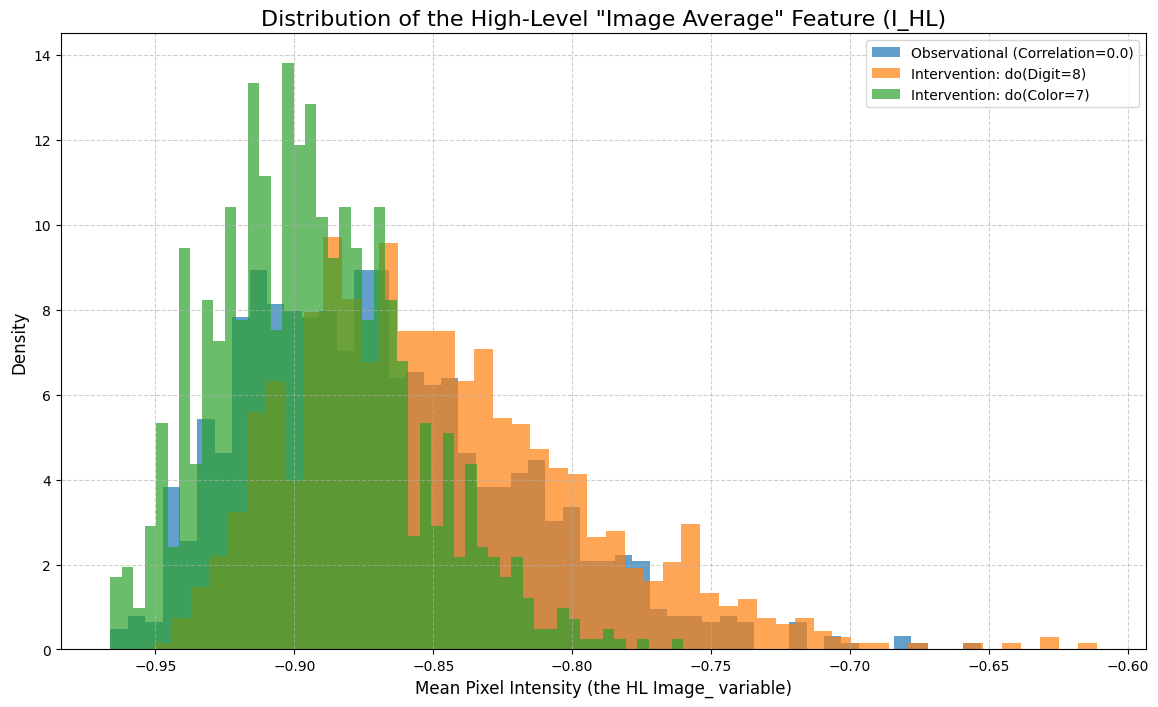

--- Distribution Statistics for HL 'Image_' Variable ---

Observational (Correlation=0.0):
  Mean:    -0.8678
  Std Dev: 0.0501
  Min:     -0.9662
  Max:     -0.6530

Intervention do(Digit=8):
  Mean:    -0.8478
  Std Dev: 0.0518

Intervention do(Color=7):
  Mean:    -0.8932
  Std Dev: 0.0347


In [6]:
# --- 1. Extract the "Image Average" variable ---
# This variable is the last column of the HL data tensors

# Get observational data
obs_hl_data = Dhl_samples[None]
obs_averages = obs_hl_data[:, -1].numpy()

# Get a "do(Digit=...)" intervention
# We find the intervention object in the Dhl_samples keys
eta_do_digit_8 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {D_HL: 8}:
        eta_do_digit_8 = eta
        break
        
int_digit_data = Dhl_samples[eta_do_digit_8]
int_digit_averages = int_digit_data[:, -1].numpy()

# Get a "do(Color=...)" intervention
eta_do_color_7 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {C_HL: 7}:
        eta_do_color_7 = eta
        break

int_color_data = Dhl_samples[eta_do_color_7]
int_color_averages = int_color_data[:, -1].numpy()


# --- 2. Plot the Histograms ---
plt.figure(figsize=(14, 8))
plt.hist(obs_averages, bins=50, alpha=0.7, label=f'Observational (Correlation=0.0)', density=True)
plt.hist(int_digit_averages, bins=50, alpha=0.7, label=f'Intervention: do(Digit=8)', density=True)
plt.hist(int_color_averages, bins=50, alpha=0.7, label=f'Intervention: do(Color=7)', density=True)

plt.title('Distribution of the High-Level "Image Average" Feature (I_HL)', fontsize=16)
plt.xlabel('Mean Pixel Intensity (the HL Image_ variable)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 3. Print Descriptive Statistics ---
print("--- Distribution Statistics for HL 'Image_' Variable ---")
print(f"\nObservational (Correlation=0.0):")
print(f"  Mean:    {obs_averages.mean():.4f}")
print(f"  Std Dev: {obs_averages.std():.4f}")
print(f"  Min:     {obs_averages.min():.4f}")
print(f"  Max:     {obs_averages.max():.4f}")

print(f"\nIntervention do(Digit=8):")
print(f"  Mean:    {int_digit_averages.mean():.4f}")
print(f"  Std Dev: {int_digit_averages.std():.4f}")

print(f"\nIntervention do(Color=7):")
print(f"  Mean:    {int_color_averages.mean():.4f}")
print(f"  Std Dev: {int_color_averages.std():.4f}")

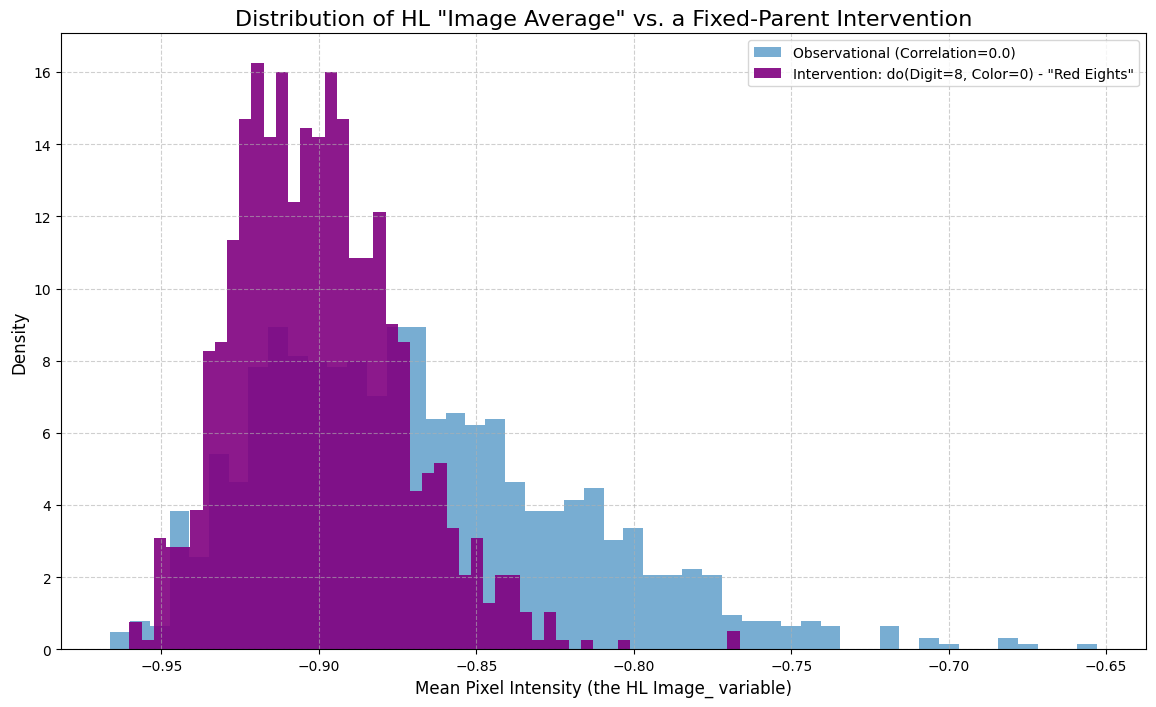

--- Distribution Statistics for HL 'Image_' Variable ---

Observational (Correlation=0.0):
  Mean:    -0.8678
  Std Dev: 0.0501

Intervention do(Digit=8, Color=0):
  Mean:    -0.9002
  Std Dev: 0.0262


In [7]:
# --- 1. Define HL variable names (from data_generator.py) ---
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

# --- 2. Extract Data for the new intervention ---

# Get observational data (for comparison)
obs_hl_data = Dhl_samples[None]
obs_averages = obs_hl_data[:, -1].numpy()

# Find the intervention for "red eights"
# From data_generator.py:
#   - "red" is Color = 0
#   - "eight" is Digit = 8
target_intervention = {D_HL: 8, C_HL: 0} 
eta_do_digit_8_color_0 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == target_intervention:
        eta_do_digit_8_color_0 = eta
        break

if eta_do_digit_8_color_0 is None:
    print(f"Error: Could not find intervention for {target_intervention}")
else:
    # Extract the image average (last column) for this intervention
    int_d8_c0_data = Dhl_samples[eta_do_digit_8_color_0]
    int_d8_c0_averages = int_d8_c0_data[:, -1].numpy()

    # --- 3. Plot the Histograms ---
    plt.figure(figsize=(14, 8))
    plt.hist(obs_averages, bins=50, alpha=0.6, label=f'Observational (Correlation=0.0)', density=True)
    plt.hist(int_d8_c0_averages, bins=50, alpha=0.9, label=f'Intervention: do(Digit=8, Color=0) - "Red Eights"', density=True, color='purple')

    plt.title('Distribution of HL "Image Average" vs. a Fixed-Parent Intervention', fontsize=16)
    plt.xlabel('Mean Pixel Intensity (the HL Image_ variable)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # --- 4. Print Descriptive Statistics ---
    print("--- Distribution Statistics for HL 'Image_' Variable ---")
    print(f"\nObservational (Correlation=0.0):")
    print(f"  Mean:    {obs_averages.mean():.4f}")
    print(f"  Std Dev: {obs_averages.std():.4f}")

    print(f"\nIntervention do(Digit=8, Color=0):")
    print(f"  Mean:    {int_d8_c0_averages.mean():.4f}")
    print(f"  Std Dev: {int_d8_c0_averages.std():.4f}")

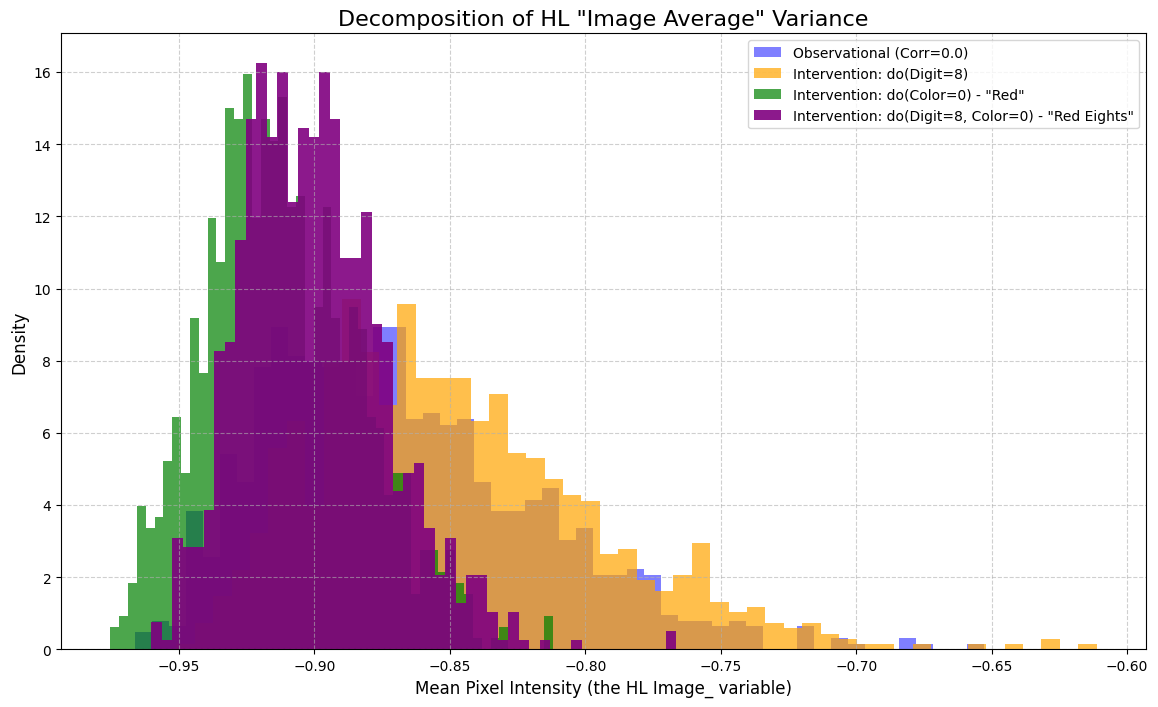

--- Distribution Statistics for HL 'Image_' Variable ---

Observational (Corr=0.0):
  Mean:    -0.8678
  Std Dev: 0.0501 (Total Variance)

Intervention do(Digit=8):
  Mean:    -0.8478
  Std Dev: 0.0518 (Variance from Color)

Intervention do(Color=0) - 'Red':
  Mean:    -0.9115
  Std Dev: 0.0284 (Variance from Digit)

Intervention do(Digit=8, Color=0) - 'Red Eights':
  Mean:    -0.9002
  Std Dev: 0.0262 (Base Noise U_image)


In [8]:
# --- 1. Define HL variable names (from data_generator.py) ---
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

# --- 2. Extract Data for all four scenarios ---

# (1) Observational
obs_hl_data = Dhl_samples[None]
obs_averages = obs_hl_data[:, -1].numpy()

# (2) Intervention: do(Digit=8)
eta_do_digit_8 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {D_HL: 8}:
        eta_do_digit_8 = eta
        break
int_digit_data = Dhl_samples[eta_do_digit_8]
int_digit_averages = int_digit_data[:, -1].numpy()

# (3) Intervention: do(Color=0) - "Red"
# From data_generator.py, "red" is Color 0
eta_do_color_0 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {C_HL: 0}:
        eta_do_color_0 = eta
        break
int_color_data = Dhl_samples[eta_do_color_0]
int_color_averages = int_color_data[:, -1].numpy()

# (4) Intervention: do(Digit=8, Color=0) - "Red Eights"
eta_do_digit_8_color_0 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {D_HL: 8, C_HL: 0}:
        eta_do_digit_8_color_0 = eta
        break
int_d8_c0_data = Dhl_samples[eta_do_digit_8_color_0]
int_d8_c0_averages = int_d8_c0_data[:, -1].numpy()


# --- 3. Plot all four Histograms ---
plt.figure(figsize=(14, 8))
plt.hist(obs_averages, bins=50, alpha=0.5, label=f'Observational (Corr=0.0)', density=True, color='blue')
plt.hist(int_digit_averages, bins=50, alpha=0.7, label=f'Intervention: do(Digit=8)', density=True, color='orange')
plt.hist(int_color_averages, bins=50, alpha=0.7, label=f'Intervention: do(Color=0) - "Red"', density=True, color='green')
plt.hist(int_d8_c0_averages, bins=50, alpha=0.9, label=f'Intervention: do(Digit=8, Color=0) - "Red Eights"', density=True, color='purple')

plt.title('Decomposition of HL "Image Average" Variance', fontsize=16)
plt.xlabel('Mean Pixel Intensity (the HL Image_ variable)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 4. Print Descriptive Statistics ---
print("--- Distribution Statistics for HL 'Image_' Variable ---")
print(f"\nObservational (Corr=0.0):")
print(f"  Mean:    {obs_averages.mean():.4f}")
print(f"  Std Dev: {obs_averages.std():.4f} (Total Variance)")

print(f"\nIntervention do(Digit=8):")
print(f"  Mean:    {int_digit_averages.mean():.4f}")
print(f"  Std Dev: {int_digit_averages.std():.4f} (Variance from Color)")

print(f"\nIntervention do(Color=0) - 'Red':")
print(f"  Mean:    {int_color_averages.mean():.4f}")
print(f"  Std Dev: {int_color_averages.std():.4f} (Variance from Digit)")

print(f"\nIntervention do(Digit=8, Color=0) - 'Red Eights':")
print(f"  Mean:    {int_d8_c0_averages.mean():.4f}")
print(f"  Std Dev: {int_d8_c0_averages.std():.4f} (Base Noise U_image)")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9843137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9607843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9843137].
Clipping input data to the valid range for im

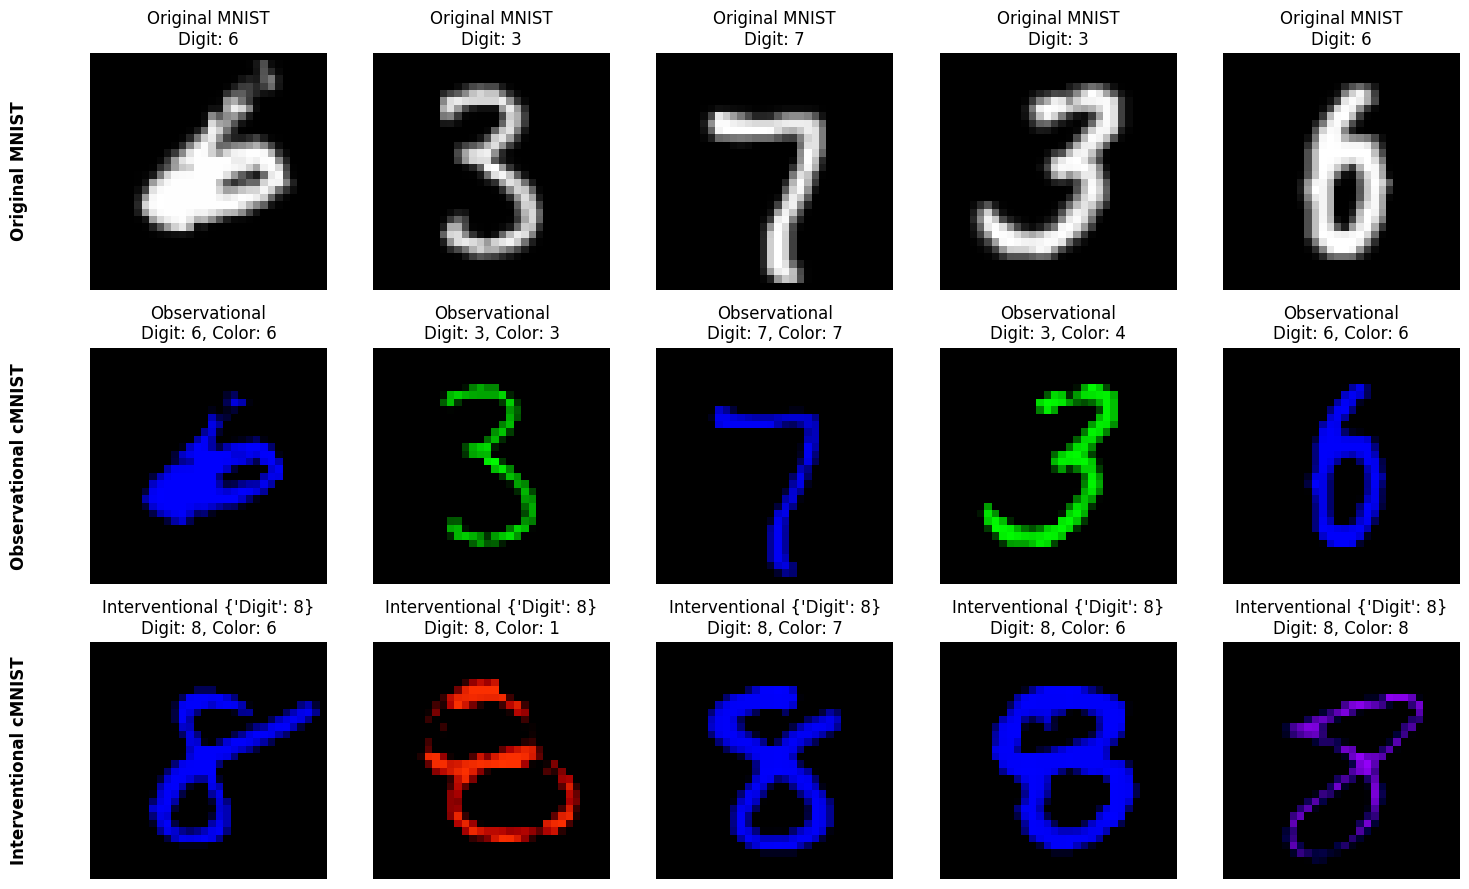

In [9]:
# Visualize sample images: Original MNIST, Observational, and Interventional
obs_data = Dll_samples[None]
obs_images, obs_shapes, obs_digits, obs_colors = obs_data

iota1 = list(omega.keys())[2]  # Pick an intervention
int_data = Dll_samples[iota1]
int_images, int_shapes, int_digits, int_colors = int_data

n_samples = 5
fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))

for i in range(n_samples):
    # Row 1: Original MNIST shapes (grayscale)
    shape = obs_shapes[i].squeeze()  # Remove channel dimension
    axes[0, i].imshow(shape, cmap='gray')
    axes[0, i].set_title(f'Original MNIST\nDigit: {obs_digits[i].item()}')
    axes[0, i].axis('off')
    
    # Row 2: Observational colored images
    img = obs_images[i].permute(1, 2, 0)  # Convert from CHW to HWC
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Observational\nDigit: {obs_digits[i].item()}, Color: {obs_colors[i].item()}')
    axes[1, i].axis('off')
    
    # Row 3: Interventional colored images
    int_img = int_images[i].permute(1, 2, 0)  # Convert from CHW to HWC
    axes[2, i].imshow(int_img)
    axes[2, i].set_title(f'Interventional {iota1.vv()}\nDigit: {int_digits[i].item()}, Color: {int_colors[i].item()}')
    axes[2, i].axis('off')

# Add row labels
axes[0, 0].text(-0.3, 0.5, 'Original MNIST', transform=axes[0, 0].transAxes, 
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].text(-0.3, 0.5, 'Observational cMNIST', transform=axes[1, 0].transAxes, 
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[2, 0].text(-0.3, 0.5, 'Interventional cMNIST', transform=axes[2, 0].transAxes, 
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Observational data defined:
  - Low-level shape: torch.Size([1000, 3, 32, 32]) (images)
  - High-level shape: torch.Size([1000, 21])
COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS

1. RESIDUAL DIAGNOSTICS
------------------------------


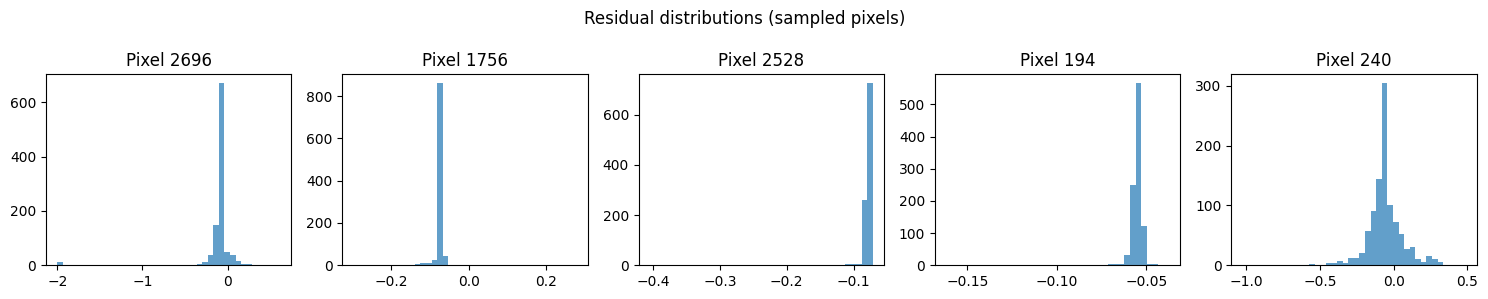

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.97147423..0.9214881].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5389443..0.42434978].


R² of predicting residual (pixel 2696) from labels: 0.0291
✓ Residual appears independent of labels (good exogenous noise).


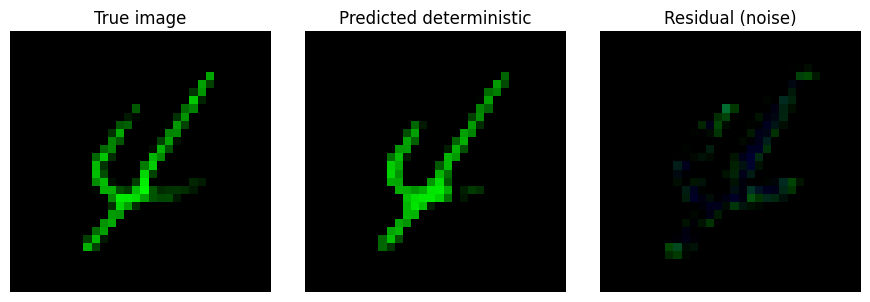


2. COUNTERFACTUAL CONSISTENCY SCORES
----------------------------------------


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


Consistency Scores:
  digit_variance: 0.151206
  color_variance: 0.004143
  noise_corr: 1.000000

3. COLOR HUE ANALYSIS
-------------------------
Mean pairwise JS divergence over hue histograms: 0.6107

4. VISUAL COUNTERFACTUAL SWEEP
-----------------------------------


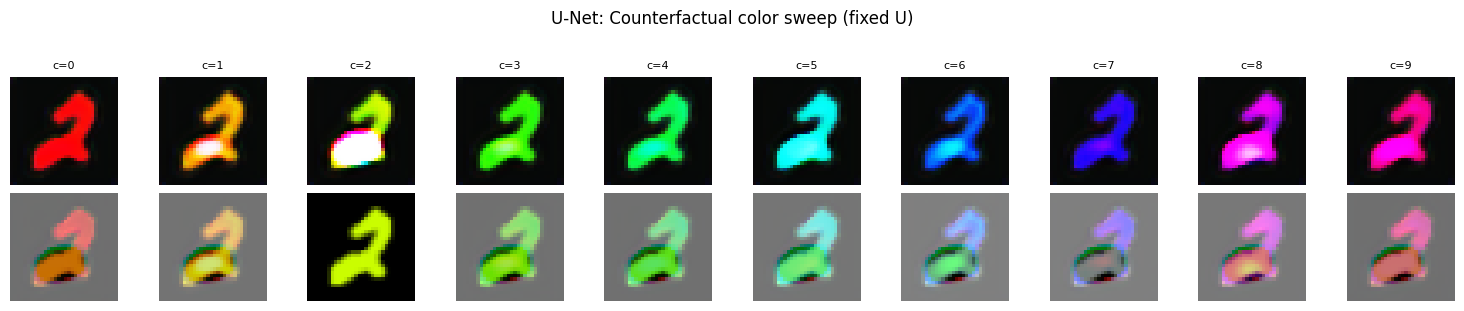


5. SUMMARY INTERPRETATION
------------------------------
Residual Independence:
Residuals are independent of labels (good)

Counterfactual Consistency:
Significant digit shape changes (needs improvement)
Low color sensitivity (needs improvement)
Noise component is stable (excellent)

Color Hue Diversity: 0.6107
High color diversity (good)

DIAGNOSTICS COMPLETE


In [10]:
# ===== COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS =====

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define the observational data tuple from loaded data
ll_obs_data_tuple = Dll_samples[None]  # Get observational (no intervention) data
hl_obs_data = Dhl_samples[None]        # Get observational high-level data

print("Observational data defined:")
print(f"  - Low-level shape: {ll_obs_data_tuple[0].shape} (images)")
print(f"  - High-level shape: {hl_obs_data.shape}")

def comprehensive_counterfactual_diagnostics(ll_obs_data_tuple, ll_model_unet, U_ll_hat_unet, 
                                         num_samples=5, bins=36, v_thresh=0.1):
    """
    Comprehensive diagnostics for counterfactual analysis including:
    1. Residual diagnostics (independence, distribution)
    2. Counterfactual consistency scores
    3. Color hue analysis
    4. Visual counterfactual sweep
    """
    
    print("=" * 60)
    print("COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS")
    print("=" * 60)
    
    # Unpack data
    final_images, img_shapes, digits, colors = ll_obs_data_tuple
    
    # ===== 1. RESIDUAL DIAGNOSTICS =====
    print("\n1. RESIDUAL DIAGNOSTICS")
    print("-" * 30)
    
    # Flatten residuals for analysis
    U = U_ll_hat_unet.view(U_ll_hat_unet.size(0), -1).detach().cpu().numpy()
    
    # Sample pixels for analysis
    sample_pixels = np.random.choice(U.shape[1], size=num_samples, replace=False)
    resid_samples = U[:, sample_pixels]
    
    # Histogram check
    fig, axs = plt.subplots(1, num_samples, figsize=(15, 3))
    for i, pix in enumerate(sample_pixels):
        axs[i].hist(resid_samples[:, i], bins=40, alpha=0.7)
        axs[i].set_title(f"Pixel {pix}")
    plt.suptitle("Residual distributions (sampled pixels)")
    plt.tight_layout()
    plt.show()
    
    # Dependence check
    digits_np = digits.cpu().numpy()
    colors_np = colors.cpu().numpy()
    X = np.stack([digits_np, colors_np], axis=1)
    
    # Test first sampled pixel
    y = resid_samples[:, 0]
    linreg = LinearRegression().fit(X, y)
    y_pred = linreg.predict(X)
    r2_resid = r2_score(y, y_pred)
    
    print(f"R² of predicting residual (pixel {sample_pixels[0]}) from labels: {r2_resid:.4f}")
    if abs(r2_resid) < 0.05:
        print("✓ Residual appears independent of labels (good exogenous noise).")
    else:
        print("⚠ Residual still has label-dependent structure.")
    
    # Visual sanity check
    idx = np.random.randint(0, len(U_ll_hat_unet))
    resid_img = U_ll_hat_unet[idx].permute(1,2,0).detach().cpu().numpy()
    true_img = final_images[idx].permute(1,2,0).cpu().numpy()
    pred_img = (true_img - resid_img)
    
    fig, axs = plt.subplots(1, 3, figsize=(9,3))
    axs[0].imshow(true_img, cmap="gray"); axs[0].set_title("True image")
    axs[1].imshow(pred_img, cmap="gray"); axs[1].set_title("Predicted deterministic")
    axs[2].imshow(resid_img, cmap="gray"); axs[2].set_title("Residual (noise)")
    for ax in axs: ax.axis("off")
    plt.tight_layout()
    plt.show()
    
    # ===== 2. COUNTERFACTUAL CONSISTENCY SCORES =====
    print("\n2. COUNTERFACTUAL CONSISTENCY SCORES")
    print("-" * 40)
    
    # Helper function for image scaling
    def to01(img_t):
        x = img_t.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1.0) / 2.0
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        return x.clamp(0, 1).numpy()
    
    # Generate counterfactuals
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ll_model_unet = ll_model_unet.to(device).eval()
    
    idx = np.random.randint(0, len(U_ll_hat_unet))
    with torch.no_grad():
        base_shape = img_shapes[idx:idx+1].to(device)
        base_digit = digits[idx:idx+1].to(device)
        U_fixed = U_ll_hat_unet[idx:idx+1].to(device)
        
        dets = []
        outs = []
        for c in range(10):
            c_tensor = torch.tensor([c], device=device)
            det = ll_model_unet(base_shape, base_digit, c_tensor)
            ycf = det + U_fixed
            dets.append(det.cpu())
            outs.append(ycf.cpu())
    
    # Calculate consistency scores
    D = torch.stack(dets, dim=0)
    O = torch.stack(outs, dim=0)
    
    # Digit shape invariance
    D_gray = D.mean(1)
    var_digit = D_gray.var(0).mean().item()
    
    # Color sensitivity
    mean_colors = O.view(O.size(0), O.size(1), -1).mean(-1)
    var_color = mean_colors.var(0).mean().item()
    
    # Noise stability
    U = O - D
    U_flat = U.view(U.size(0), -1).cpu().numpy()
    corr_mat = np.corrcoef(U_flat)
    mean_corr = (corr_mat[np.triu_indices_from(corr_mat, k=1)]).mean()
    
    consistency_scores = {
        "digit_variance": var_digit,
        "color_variance": var_color,
        "noise_corr": mean_corr
    }
    
    print("Consistency Scores:")
    for key, value in consistency_scores.items():
        print(f"  {key}: {value:.6f}")
    
    # ===== 3. COLOR HUE ANALYSIS =====
    print("\n3. COLOR HUE ANALYSIS")
    print("-" * 25)
    
    def hue_hist(img_chw, bins=36, v_thresh=0.1):
        x = img_chw.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1) / 2
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        
        rgb = x.permute(1,2,0).numpy()
        hsv = rgb_to_hsv(rgb)
        H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]
        
        mask = V > v_thresh
        if mask.sum() == 0:
            return np.ones(bins) / bins
        
        h = H[mask].ravel()
        hist, _ = np.histogram(h, bins=bins, range=(0,1), density=False)
        hist = hist.astype(np.float64)
        hist /= hist.sum() + 1e-12
        return hist
    
    def js_divergence(p, q):
        m = 0.5*(p+q)
        def kl(a,b):
            a = np.clip(a, 1e-12, 1.0)
            b = np.clip(b, 1e-12, 1.0)
            return np.sum(a * np.log(a/b))
        return 0.5*kl(p,m) + 0.5*kl(q,m)
    
    def color_hue_js_score(dets, bins=36, v_thresh=0.1):
        Hs = [hue_hist(det[0], bins=bins, v_thresh=v_thresh) for det in dets]
        n = len(Hs)
        js_vals = []
        for i in range(n):
            for j in range(i+1, n):
                js_vals.append(js_divergence(Hs[i], Hs[j]))
        return float(np.mean(js_vals)) if js_vals else 0.0
    
    js_hue = color_hue_js_score(dets, bins=bins, v_thresh=v_thresh)
    print(f"Mean pairwise JS divergence over hue histograms: {js_hue:.4f}")
    
    # ===== 4. VISUAL COUNTERFACTUAL SWEEP =====
    print("\n4. VISUAL COUNTERFACTUAL SWEEP")
    print("-" * 35)
    
    # Plot counterfactuals
    fig, axs = plt.subplots(2, 10, figsize=(15, 3))
    for c in range(10):
        axs[0, c].imshow(to01(dets[c][0].permute(1,2,0))); axs[0, c].axis("off")
        axs[0, c].set_title(f"c={c}", fontsize=8)
        axs[1, c].imshow(to01(outs[c][0].permute(1,2,0))); axs[1, c].axis("off")
    axs[0,0].set_ylabel("deterministic", fontsize=9)
    axs[1,0].set_ylabel("with noise", fontsize=9)
    plt.suptitle("U-Net: Counterfactual color sweep (fixed U)", y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ===== 5. SUMMARY INTERPRETATION =====
    print("\n5. SUMMARY INTERPRETATION")
    print("-" * 30)
    
    print("Residual Independence:")
    if abs(r2_resid) < 0.05:
        print("Residuals are independent of labels (good)")
    else:
        print("Residuals still depend on labels (needs improvement)")
    
    print("\nCounterfactual Consistency:")
    if var_digit < 0.01:
        print("Digit shape preserved across colors (good)")
    elif var_digit < 0.1:
        print("Moderate digit shape changes (acceptable)")
    else:
        print("Significant digit shape changes (needs improvement)")
    
    if var_color > 0.1:
        print("Colors change appropriately (good)")
    elif var_color > 0.01:
        print("Moderate color sensitivity (acceptable)")
    else:
        print("Low color sensitivity (needs improvement)")
    
    if mean_corr > 0.95:
        print("Noise component is stable (excellent)")
    elif mean_corr > 0.8:
        print("Noise component is mostly stable (good)")
    else:
        print("Noise component varies (needs improvement)")
    
    print(f"\nColor Hue Diversity: {js_hue:.4f}")
    if js_hue > 0.3:
        print("High color diversity (good)")
    elif js_hue > 0.1:
        print("Moderate color diversity (acceptable)")
    else:
        print("Low color diversity (needs improvement)")
    
    print("\n" + "=" * 60)
    print("DIAGNOSTICS COMPLETE")
    print("=" * 60)
    
    return {
        'residual_r2': r2_resid,
        'consistency_scores': consistency_scores,
        'js_hue': js_hue,
        'dets': dets,
        'outs': outs
    }

# Run comprehensive diagnostics
results = comprehensive_counterfactual_diagnostics(
    ll_obs_data_tuple, 
    ll_model,  # Use ll_model instead of ll_model_unet
    U_ll_hat,  # Use U_ll_hat instead of U_ll_hat_unet
    num_samples=5,
    bins=36,
    v_thresh=0.1
)

GAUSSIANITY TESTS FOR NOISE

1. LOW-LEVEL NOISE GAUSSIANITY
----------------------------------------
Pixel 964:
  D'Agostino-Pearson: stat=1418.3634, p=0.0000
  Shapiro-Wilk: stat=0.5061, p=0.0000
  Anderson-Darling: stat=91.2774, critical=0.7840

Pixel 853:
  D'Agostino-Pearson: stat=376.3815, p=0.0000
  Shapiro-Wilk: stat=0.8172, p=0.0000
  Anderson-Darling: stat=59.1638, critical=0.7840

Pixel 2990:
  D'Agostino-Pearson: stat=306.7657, p=0.0000
  Shapiro-Wilk: stat=0.8174, p=0.0000
  Anderson-Darling: stat=57.8999, critical=0.7840

Pixel 2810:
  D'Agostino-Pearson: stat=396.7826, p=0.0000
  Shapiro-Wilk: stat=0.5913, p=0.0000
  Anderson-Darling: stat=147.8538, critical=0.7840

Pixel 2617:
  D'Agostino-Pearson: stat=212.7602, p=0.0000
  Shapiro-Wilk: stat=0.7630, p=0.0000
  Anderson-Darling: stat=80.9610, critical=0.7840

Pixel 1183:
  D'Agostino-Pearson: stat=222.9449, p=0.0000
  Shapiro-Wilk: stat=0.9254, p=0.0000
  Anderson-Darling: stat=15.8704, critical=0.7840

Pixel 1175:
  D'A

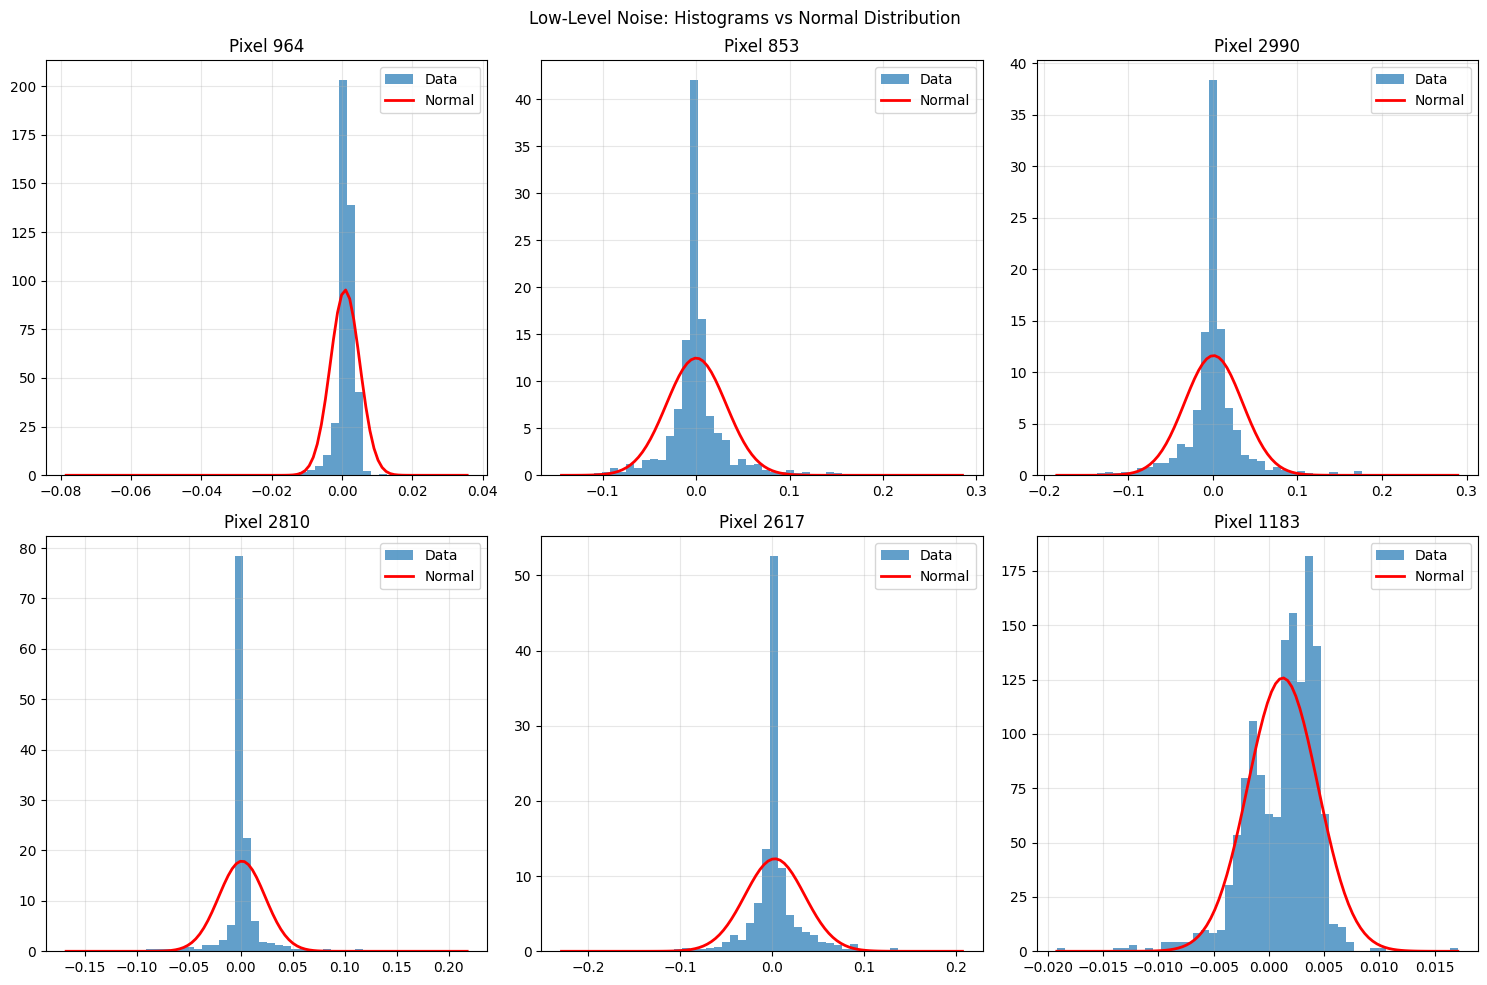

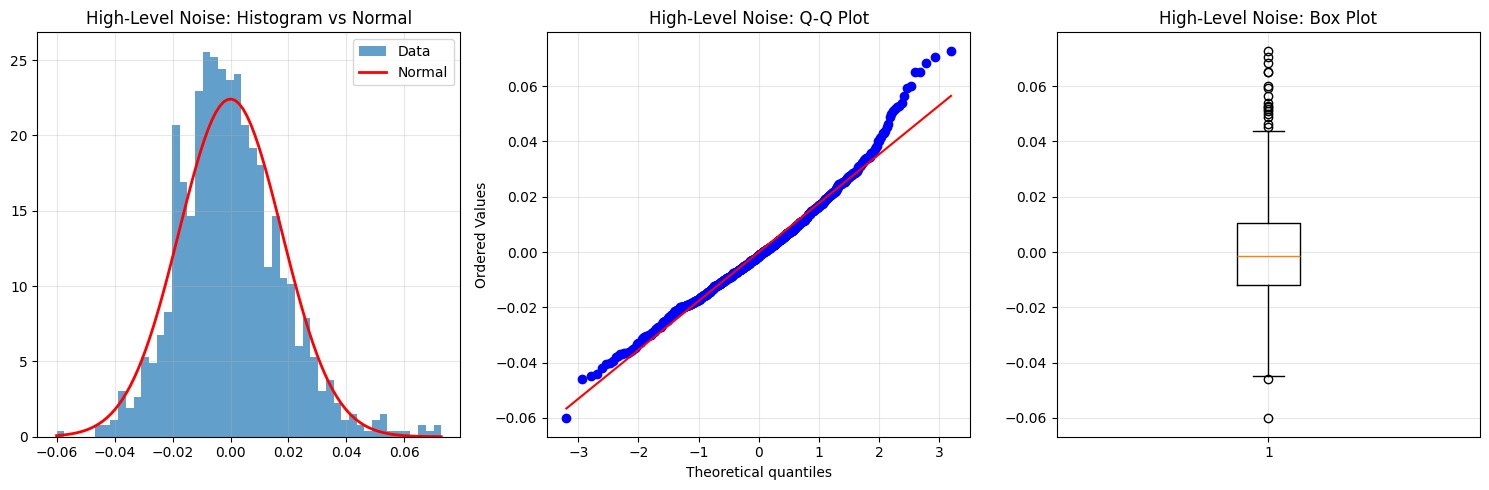


4. SUMMARY STATISTICS
-------------------------
Low-Level Noise:
  Mean of means: 0.000661 (should be ~0)
  Mean of stds: 0.026932
  Mean skewness: 0.352114 (should be ~0)
  Mean kurtosis: 37.895958 (should be ~0)

High-Level Noise:
  Mean: -0.000049 (should be ~0)
  Std: 0.017794
  Skewness: 0.537660 (should be ~0)
  Kurtosis: 1.062383 (should be ~0)

5. GAUSSIANITY INTERPRETATION
-----------------------------------
Low-Level Noise:
✗ Clearly non-Gaussian (p < 0.01)

High-Level Noise:
✗ Clearly non-Gaussian (p < 0.01)

GAUSSIANITY TESTS COMPLETE


In [19]:
# ===== GAUSSIANITY TESTS FOR NOISE =====

import scipy.stats as stats
from scipy.stats import normaltest, shapiro, anderson
import numpy as np
import matplotlib.pyplot as plt

def test_noise_gaussianity(U_ll_hat, U_hl_hat, num_samples=1000):
    """
    Comprehensive Gaussianity tests for both low-level and high-level noise.
    """
    print("=" * 60)
    print("GAUSSIANITY TESTS FOR NOISE")
    print("=" * 60)
    
    # ===== 1. LOW-LEVEL NOISE GAUSSIANITY =====
    print("\n1. LOW-LEVEL NOISE GAUSSIANITY")
    print("-" * 40)
    
    # Flatten low-level noise for analysis
    U_ll_flat = U_ll_hat.view(U_ll_hat.size(0), -1).detach().cpu().numpy()
    
    # Sample random pixels for testing
    n_pixels = min(num_samples, U_ll_flat.shape[1])
    sample_pixels = np.random.choice(U_ll_flat.shape[1], size=n_pixels, replace=False)
    U_ll_samples = U_ll_flat[:, sample_pixels]
    
    # Test each sampled pixel
    ll_results = []
    for i, pixel in enumerate(sample_pixels[:10]):  # Test first 10 pixels
        pixel_data = U_ll_samples[:, i]
        
        # D'Agostino and Pearson's test
        stat_dp, p_dp = normaltest(pixel_data)
        
        # Shapiro-Wilk test (for smaller samples)
        if len(pixel_data) <= 5000:
            stat_sw, p_sw = shapiro(pixel_data)
        else:
            stat_sw, p_sw = np.nan, np.nan
        
        # Anderson-Darling test
        stat_ad, critical_values, significance_levels = anderson(pixel_data, dist='norm')
        
        ll_results.append({
            'pixel': pixel,
            'dp_stat': stat_dp,
            'dp_p': p_dp,
            'sw_stat': stat_sw,
            'sw_p': p_sw,
            'ad_stat': stat_ad,
            'ad_critical': critical_values[2]  # 5% significance level
        })
        
        print(f"Pixel {pixel}:")
        print(f"  D'Agostino-Pearson: stat={stat_dp:.4f}, p={p_dp:.4f}")
        if not np.isnan(p_sw):
            print(f"  Shapiro-Wilk: stat={stat_sw:.4f}, p={p_sw:.4f}")
        print(f"  Anderson-Darling: stat={stat_ad:.4f}, critical={critical_values[2]:.4f}")
        print()
    
    # ===== 2. HIGH-LEVEL NOISE GAUSSIANITY =====
    print("\n2. HIGH-LEVEL NOISE GAUSSIANITY")
    print("-" * 40)
    
    U_hl_flat = U_hl_hat.detach().cpu().numpy().flatten()
    
    # D'Agostino and Pearson's test
    stat_dp, p_dp = normaltest(U_hl_flat)
    
    # Shapiro-Wilk test
    if len(U_hl_flat) <= 5000:
        stat_sw, p_sw = shapiro(U_hl_flat)
    else:
        stat_sw, p_sw = np.nan, np.nan
    
    # Anderson-Darling test
    stat_ad, critical_values, significance_levels = anderson(U_hl_flat, dist='norm')
    
    print(f"D'Agostino-Pearson: stat={stat_dp:.4f}, p={p_dp:.4f}")
    if not np.isnan(p_sw):
        print(f"Shapiro-Wilk: stat={stat_sw:.4f}, p={p_sw:.4f}")
    print(f"Anderson-Darling: stat={stat_ad:.4f}, critical={critical_values[2]:.4f}")
    
    # ===== 3. VISUAL GAUSSIANITY CHECKS =====
    print("\n3. VISUAL GAUSSIANITY CHECKS")
    print("-" * 35)
    
    # Low-level noise visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Sample a few pixels for visualization
    sample_pixels_viz = sample_pixels[:6]
    
    for i, pixel in enumerate(sample_pixels_viz):
        row, col = i // 3, i % 3
        
        # Histogram
        pixel_data = U_ll_samples[:, i]
        axes[row, col].hist(pixel_data, bins=50, density=True, alpha=0.7, label='Data')
        
        # Overlay normal distribution
        mu, sigma = pixel_data.mean(), pixel_data.std()
        x = np.linspace(pixel_data.min(), pixel_data.max(), 100)
        axes[row, col].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
        axes[row, col].set_title(f'Pixel {pixel}')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
    
    plt.suptitle('Low-Level Noise: Histograms vs Normal Distribution')
    plt.tight_layout()
    plt.show()
    
    # High-level noise visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Histogram
    axes[0].hist(U_hl_flat, bins=50, density=True, alpha=0.7, label='Data')
    mu_hl, sigma_hl = U_hl_flat.mean(), U_hl_flat.std()
    x_hl = np.linspace(U_hl_flat.min(), U_hl_flat.max(), 100)
    axes[0].plot(x_hl, stats.norm.pdf(x_hl, mu_hl, sigma_hl), 'r-', linewidth=2, label='Normal')
    axes[0].set_title('High-Level Noise: Histogram vs Normal')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Q-Q plot
    stats.probplot(U_hl_flat, dist="norm", plot=axes[1])
    axes[1].set_title('High-Level Noise: Q-Q Plot')
    axes[1].grid(True, alpha=0.3)
    
    # Box plot
    axes[2].boxplot(U_hl_flat)
    axes[2].set_title('High-Level Noise: Box Plot')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ===== 4. SUMMARY STATISTICS =====
    print("\n4. SUMMARY STATISTICS")
    print("-" * 25)
    
    # Low-level noise summary
    ll_means = U_ll_samples.mean(axis=0)
    ll_stds = U_ll_samples.std(axis=0)
    ll_skews = stats.skew(U_ll_samples, axis=0)
    ll_kurtoses = stats.kurtosis(U_ll_samples, axis=0)
    
    print("Low-Level Noise:")
    print(f"  Mean of means: {ll_means.mean():.6f} (should be ~0)")
    print(f"  Mean of stds: {ll_stds.mean():.6f}")
    print(f"  Mean skewness: {ll_skews.mean():.6f} (should be ~0)")
    print(f"  Mean kurtosis: {ll_kurtoses.mean():.6f} (should be ~0)")
    
    # High-level noise summary
    print("\nHigh-Level Noise:")
    print(f"  Mean: {U_hl_flat.mean():.6f} (should be ~0)")
    print(f"  Std: {U_hl_flat.std():.6f}")
    print(f"  Skewness: {stats.skew(U_hl_flat):.6f} (should be ~0)")
    print(f"  Kurtosis: {stats.kurtosis(U_hl_flat):.6f} (should be ~0)")
    
    # ===== 5. GAUSSIANITY INTERPRETATION =====
    print("\n5. GAUSSIANITY INTERPRETATION")
    print("-" * 35)
    
    # Low-level interpretation
    dp_p_values = [r['dp_p'] for r in ll_results]
    mean_dp_p = np.mean(dp_p_values)
    
    print("Low-Level Noise:")
    if mean_dp_p > 0.05:
        print("✓ Appears Gaussian (p > 0.05 for D'Agostino-Pearson test)")
    elif mean_dp_p > 0.01:
        print("⚠ Moderately non-Gaussian (0.01 < p < 0.05)")
    else:
        print("✗ Clearly non-Gaussian (p < 0.01)")
    
    # High-level interpretation
    print("\nHigh-Level Noise:")
    if p_dp > 0.05:
        print("✓ Appears Gaussian (p > 0.05 for D'Agostino-Pearson test)")
    elif p_dp > 0.01:
        print("⚠ Moderately non-Gaussian (0.01 < p < 0.05)")
    else:
        print("✗ Clearly non-Gaussian (p < 0.01)")
    
    print("\n" + "=" * 60)
    print("GAUSSIANITY TESTS COMPLETE")
    print("=" * 60)
    
    return {
        'll_results': ll_results,
        'hl_dp_stat': stat_dp,
        'hl_dp_p': p_dp,
        'hl_sw_stat': stat_sw,
        'hl_sw_p': p_sw,
        'hl_ad_stat': stat_ad,
        'hl_ad_critical': critical_values[2]
    }

# Run Gaussianity tests
gaussianity_results = test_noise_gaussianity(U_ll_hat, U_hl_hat)